# Aula 4 - Pratica com redes neurais

Execute as celulas em ordem. Primeiro, treine uma rede neural para reconhecer os digitos do `scikit-learn`. Depois, crie imagens proprias e teste a rede no desafio autoral.

## 1. Carregar o dataset de digitos

Este e o mesmo tipo de dado usado na Aula 2. Cada imagem possui 8x8 pixels, e cada pixel varia de 0 a 16.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_digits

digits = load_digits()
X = digits.data
y = digits.target

print(f"Imagens: {digits.images.shape}")
print(f"Dados X: {X.shape}")
print(f"Rotulos y: {y.shape}")
print(f"Classes: {digits.target_names}")

Imagens: (1797, 8, 8)
Dados X: (1797, 64)
Rotulos y: (1797,)
Classes: [0 1 2 3 4 5 6 7 8 9]


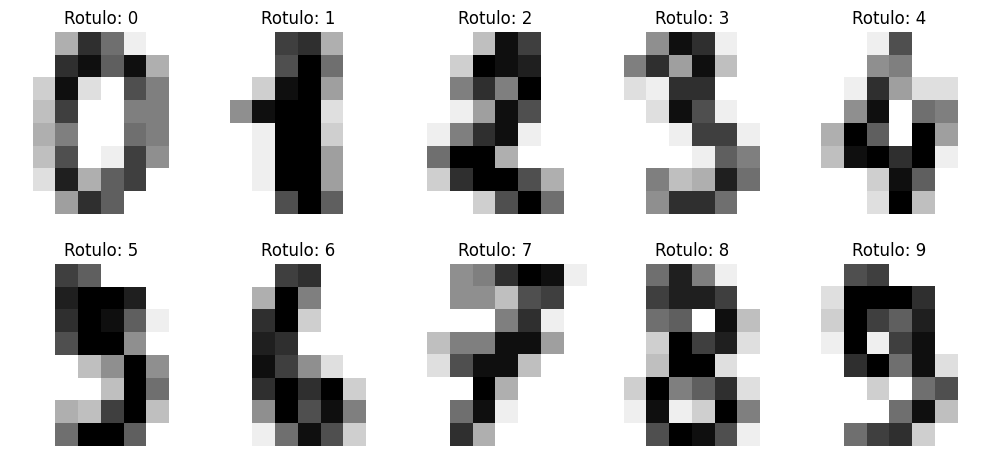

In [2]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for index, ax in enumerate(axes.ravel()):
    ax.imshow(digits.images[index], cmap="gray_r", vmin=0, vmax=16)
    ax.set_title(f"Rotulo: {y[index]}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 2. Separar treino e teste

Usaremos exatamente a mesma divisao para comparar a rede neural e o k-NN.

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

print(f"Treino: {X_train.shape}")
print(f"Teste: {X_test.shape}")

Treino: (1347, 64)
Teste: (450, 64)


## 3. Criar e treinar a rede neural

A etapa `StandardScaler` coloca os atributos em uma escala adequada. A etapa `MLPClassifier` e a rede neural. Execute e aguarde o treinamento terminar.

In [4]:
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

neural_network = Pipeline([
    ("scale", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=15,
        random_state=42,
    )),
])

neural_network.fit(X_train, y_train)
mlp = neural_network.named_steps["mlp"]
print(f"Treinamento concluido em {mlp.n_iter_} epocas.")

Treinamento concluido em 68 epocas.


## 4. Acompanhar a curva de perda

A curva registra o erro da rede a cada epoca. Observe se ele diminuiu durante o treinamento.

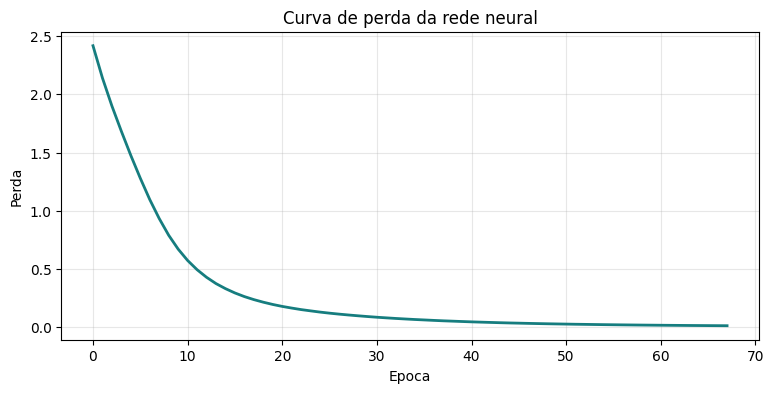

In [5]:
plt.figure(figsize=(9, 4))
plt.plot(mlp.loss_curve_, color="#167D7F", linewidth=2)
plt.xlabel("Epoca")
plt.ylabel("Perda")
plt.title("Curva de perda da rede neural")
plt.grid(alpha=0.3)
plt.show()

## 5. Avaliar no conjunto de teste

O conjunto de teste nao foi usado para ajustar os pesos da rede.

Acuracia da rede neural: 96.00%

              precision    recall  f1-score   support

           0       1.00      0.98      0.99        45
           1       0.92      0.98      0.95        46
           2       0.96      1.00      0.98        44
           3       1.00      0.96      0.98        46
           4       0.93      0.93      0.93        45
           5       0.96      0.96      0.96        46
           6       1.00      0.96      0.98        45
           7       0.93      0.96      0.95        45
           8       0.95      0.91      0.93        43
           9       0.96      0.98      0.97        45

    accuracy                           0.96       450
   macro avg       0.96      0.96      0.96       450
weighted avg       0.96      0.96      0.96       450



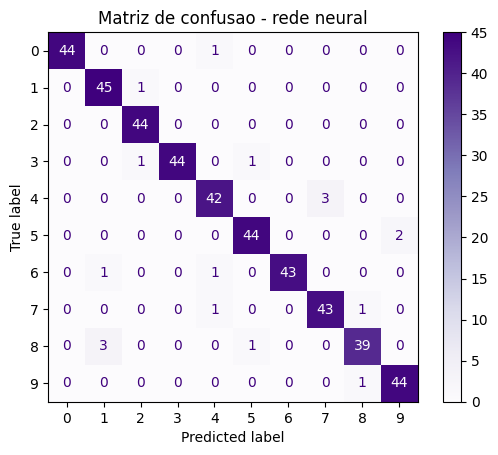

In [6]:
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report

y_pred_neural = neural_network.predict(X_test)
accuracy_neural = accuracy_score(y_test, y_pred_neural)

print(f"Acuracia da rede neural: {accuracy_neural:.2%}\n")
print(classification_report(y_test, y_pred_neural))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_neural,
    display_labels=digits.target_names,
    cmap="Purples",
)
plt.title("Matriz de confusao - rede neural")
plt.show()

## 6. Comparar a rede com o k-NN

Treinaremos novamente o algoritmo da Aula 2 usando a mesma divisao. Assim, a comparacao sera justa.

In [7]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
accuracy_knn = accuracy_score(y_test, y_pred_knn)

comparison = pd.DataFrame({
    "modelo": ["k-NN", "Rede neural MLP"],
    "acuracia_teste": [accuracy_knn, accuracy_neural],
    "erros": [sum(y_test != y_pred_knn), sum(y_test != y_pred_neural)],
})
comparison["acuracia_teste"] = (100 * comparison["acuracia_teste"]).round(2)
display(comparison.rename(columns={"acuracia_teste": "acuracia_teste (%)"}))

,modelo,acuracia_teste (%),erros
0,k-NN,98.44,7
1,Rede neural MLP,96.00,18


## 7. Investigar os erros

Nao olhe apenas a acuracia. Observe quais imagens confundiram a rede e se a previsao parece compreensivel.

Quantidade de erros: 18


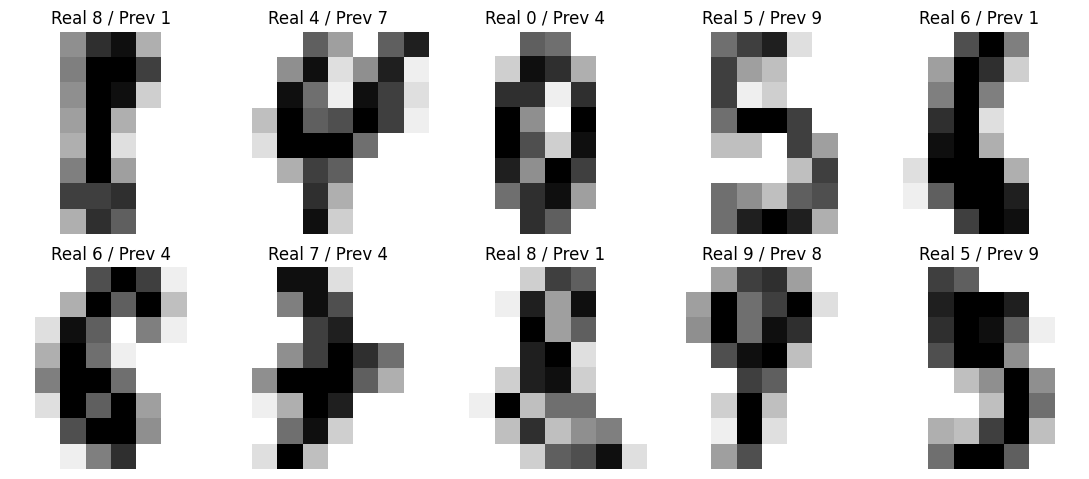

In [8]:
error_indices = np.flatnonzero(y_test != y_pred_neural)
print(f"Quantidade de erros: {len(error_indices)}")

fig, axes = plt.subplots(2, 5, figsize=(11, 5))
for ax in axes.ravel():
    ax.axis("off")
for ax, index in zip(axes.ravel(), error_indices[:10]):
    ax.imshow(X_test[index].reshape(8, 8), cmap="gray_r", vmin=0, vmax=16)
    ax.set_title(f"Real {y_test[index]} / Prev {y_pred_neural[index]}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 8. Consultar probabilidades

Troque o indice e observe a imagem, a previsao e as probabilidades atribuidas a cada classe.

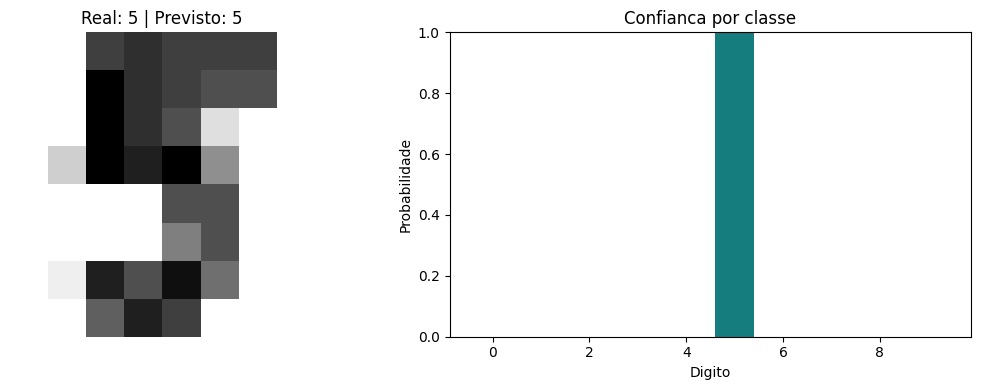

In [9]:
index = 10
image = X_test[index]
real = y_test[index]
prediction = neural_network.predict([image])[0]
probabilities = neural_network.predict_proba([image])[0]

fig, (ax_image, ax_probability) = plt.subplots(1, 2, figsize=(11, 4))
ax_image.imshow(image.reshape(8, 8), cmap="gray_r", vmin=0, vmax=16)
ax_image.set_title(f"Real: {real} | Previsto: {prediction}")
ax_image.axis("off")
ax_probability.bar(digits.target_names, probabilities, color="#167D7F")
ax_probability.set_ylim(0, 1)
ax_probability.set_xlabel("Digito")
ax_probability.set_ylabel("Probabilidade")
ax_probability.set_title("Confianca por classe")
plt.tight_layout()
plt.show()

### Fechamento do exemplo guiado

Antes do desafio, confirme que voce executou todo o pipeline, comparou os dois modelos e encontrou pelo menos um erro da rede.

# Desafio autoral - a rede reconhece os nossos digitos?

Leia `DESAFIO-IMAGENS.md`. Crie pelo menos cinco imagens representando tres ou mais digitos. Voce pode desenhar no Paint, escrever no papel e fotografar ou gerar com IA.

Crie a pasta `digitos_desafio` e nomeie cada arquivo com o rotulo correto no inicio: `7_ana.png`, `3_papel.jpg` ou `5_ia.png`.

## Planejamento do grupo

Antes de consultar a rede, registre os arquivos, a origem, o prompt utilizado quando houver IA e a previsao do grupo. Nao altere os rotulos depois de ver o resultado.

**Arquivos e origem:** as 5 imagens em `digitos_desafio/` foram geradas com o modelo de imagem Z Image (Higgsfield), pedindo um digito escrito a mao com caneta preta numa folha de papel branca, foto/scan realista, sem outro texto na imagem. Digitos usados: 1, 2, 4, 6, 8 (cinco classes).

**Prompt utilizado:** "A single handwritten digit '{d}' written by hand with a black pen on a plain white paper background, natural imperfect human handwriting stroke, centered, no other text, numbers, marks, shadow, or frame, clean flat lighting, photo scan of paper" (um por digito, trocando {d}).

**Previsao do grupo antes de rodar:** esperavamos acerto razoavel, ja que as imagens sao foto-realistas e visualmente bem legiveis pra um humano (traco de caneta claro, digito bem formado).

## Pre-processar uma imagem externa

A funcao abaixo recorta o digito, centraliza, reduz para 8x8 e converte os pixels para a escala de 0 a 16 usada no treinamento. Apenas execute esta celula.

In [10]:
from pathlib import Path
from PIL import Image

def preprocess_external_digit(path):
    image = Image.open(path).convert("L")
    array = np.asarray(image, dtype=float)

    # O dataset usa fundo escuro e traco claro.
    if array.mean() > 127:
        array = 255 - array

    threshold = max(30, 0.2 * array.max())
    coordinates = np.argwhere(array > threshold)
    if coordinates.size == 0:
        raise ValueError(f"Nenhum digito encontrado em {path}")

    y_min, x_min = coordinates.min(axis=0)
    y_max, x_max = coordinates.max(axis=0) + 1
    crop = array[y_min:y_max, x_min:x_max]

    side = max(crop.shape)
    margin = max(2, side // 5)
    canvas = np.zeros((side + 2 * margin, side + 2 * margin))
    top = (canvas.shape[0] - crop.shape[0]) // 2
    left = (canvas.shape[1] - crop.shape[1]) // 2
    canvas[top:top + crop.shape[0], left:left + crop.shape[1]] = crop

    small = Image.fromarray(canvas.astype(np.uint8)).resize(
        (8, 8),
        Image.Resampling.LANCZOS,
    )
    result = np.asarray(small, dtype=float)
    if result.max() > 0:
        result = 16 * result / result.max()
    return result

print("Funcao de pre-processamento pronta.")

Funcao de pre-processamento pronta.


## Executar o desafio

Depois de criar as imagens, substitua `None` pelo caminho da pasta, por exemplo `"digitos_desafio"`.

,arquivo,real,previsto,correto,confianca (%)
0,1_ia.png,1,4,False,99.7
1,2_ia.png,2,4,False,95.4
2,4_ia.png,4,4,True,94.0
3,6_ia.png,6,4,False,95.7
4,8_ia.png,8,4,False,99.5


Acuracia nas imagens do grupo: 20.00%


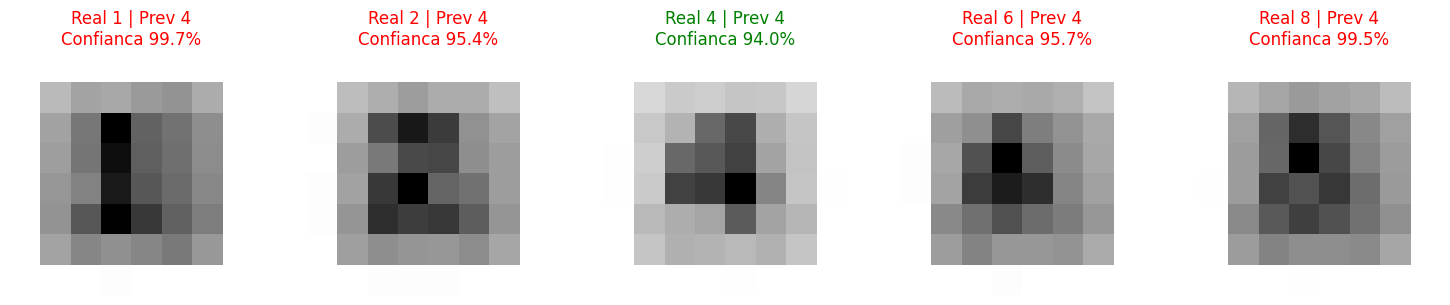

In [11]:
PASTA_DESAFIO = "digitos_desafio"  # Exemplo: "digitos_desafio"

if PASTA_DESAFIO is None:
    print("Crie as imagens, informe a pasta em PASTA_DESAFIO e execute novamente.")
else:
    challenge_folder = Path(PASTA_DESAFIO)
    files = sorted(
        path for path in challenge_folder.iterdir()
        if path.suffix.lower() in {".png", ".jpg", ".jpeg"}
    )
    assert len(files) >= 5, "Crie pelo menos cinco imagens."

    challenge_images = []
    challenge_labels = []
    for path in files:
        assert path.stem[0].isdigit(), f"O nome deve comecar com o digito correto: {path.name}"
        challenge_images.append(preprocess_external_digit(path))
        challenge_labels.append(int(path.stem[0]))

    assert len(set(challenge_labels)) >= 3, "Use pelo menos tres digitos diferentes."
    challenge_X = np.array(challenge_images).reshape(len(files), -1)
    challenge_prediction = neural_network.predict(challenge_X)
    challenge_probability = neural_network.predict_proba(challenge_X)
    challenge_confidence = challenge_probability.max(axis=1)

    challenge_result = pd.DataFrame({
        "arquivo": [path.name for path in files],
        "real": challenge_labels,
        "previsto": challenge_prediction,
        "confianca": challenge_confidence,
    })
    challenge_result["correto"] = challenge_result["real"] == challenge_result["previsto"]
    challenge_result["confianca (%)"] = (100 * challenge_result.pop("confianca")).round(1)
    display(challenge_result)
    print(f"Acuracia nas imagens do grupo: {challenge_result['correto'].mean():.2%}")

    columns = min(5, len(files))
    rows = int(np.ceil(len(files) / columns))
    fig, axes = plt.subplots(rows, columns, figsize=(3 * columns, 3 * rows))
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        ax.axis("off")
    for ax, image_external, real_external, pred_external, confidence_external in zip(
        axes, challenge_images, challenge_labels, challenge_prediction, challenge_confidence
    ):
        ax.imshow(image_external, cmap="gray_r", vmin=0, vmax=16)
        ax.set_title(
            f"Real {real_external} | Prev {pred_external}\nConfianca {confidence_external:.1%}",
            color="green" if real_external == pred_external else "red",
        )
        ax.axis("off")
    plt.tight_layout()
    plt.show()

# Fechamento e entrega

Preencha depois do desafio:

**1. Como as imagens foram produzidas:** geradas por IA (modelo Z Image, via Higgsfield), pedindo um digito escrito a mao com caneta preta em papel branco, estilo foto/scan realista. Nao foi caligrafia real nem fonte de texto.

**2. Acuracia nas imagens do grupo:** 20,00% (1 acerto em 5) com o pre-processamento original do notebook (limiar fixo). Testei tambem um limiar adaptativo (Otsu, `skimage.filters.threshold_otsu`) por curiosidade: o recorte 8x8 ficou visualmente mais limpo e reconhecivel, mas a acuracia continuou 20% (1/5) - so trocou quais imagens erraram.

**3. A maior confianca estava correta?** Nao, no pre-processamento original. A maior confianca do lote foi 99,7% no arquivo `1_ia.png`, e a rede errou: previu 4 em vez de 1. Quase todo o lote (4 de 5) foi classificado como "4" com confianca acima de 90%.

**4. Erro mais interessante e explicacao:** a rede prever "4" pra quase tudo, com confianca alta, mesmo com o pre-processamento original. Ao trocar pelo limiar de Otsu, o recorte ficou visualmente correto (dava pra reconhecer o digito no 8x8), mas a rede continuou errando a maioria - so que agora com confianca bem mais baixa (49-55% em vez de 99%), o que e mais honesto mas nao resolve o problema. Isso mostra que o erro nao era so o recorte capturar mancha errada: mesmo com o traco bem isolado, reduzir uma foto realista (com espessura, textura e antialiasing de tinta) pra 8x8 pixels produz uma distribuicao de tons diferente da caligrafia fina e uniforme que o dataset `load_digits` usa, e a rede nao generaliza bem pra essa diferenca de estilo.

**5. Diferenca observada entre o dataset e as imagens externas:** duas diferencas, uma resolvivel e outra nao so com pre-processamento. (a) Enquadramento/threshold: resolvido trocando o limiar fixo por Otsu, o recorte passou a isolar o digito corretamente. (b) Estilo do traco: nao resolvido - o dataset original tem traco fino, uniforme e sem textura (scan binarizado de caligrafia), enquanto as imagens de IA tem traco de caneta com variacao de pressao, leve textura e antialiasing que sobrevivem mesmo depois do recorte certo, e mudam a "forma" que a rede aprendeu a reconhecer.

**6. Uma melhoria nos dados ou no pre-processamento:** duas frentes. No pre-processamento, o limiar de Otsu ja e uma melhoria real (recorte mais preciso) e deveria substituir o limiar fixo. Nos dados, a melhoria mais eficaz seria re-treinar a rede incluindo exemplos com o mesmo estilo de traco das imagens externas (data augmentation com blur leve, variacao de espessura e ruido, nao so rotacao/deslocamento), pra rede aprender a generalizar pro estilo de imagem que ela vai encontrar em producao, em vez de só pro estilo limpo do dataset original.

## Checklist

- [x] Executei o exemplo guiado completo.
- [x] Comparei MLP e k-NN.
- [x] Criei cinco imagens com pelo menos tres digitos.
- [x] Registrei origem e prompts.
- [x] Testei todas as imagens.
- [x] Analisei um erro e uma limitacao.